# Segmentation-free spatial proteomics analysis (MACSima)

This notebook covers segmentation-free approaches — superpixel clustering and pixel/cell clustering with FlowSOM — for the MACSima spatial proteomics dataset. It continues from `6.proteomics_macsima.ipynb`, assuming the preprocessed `SpatialData` object is already available.

## 1. Superpixel clustering

In [1]:
from spatialdata import read_zarr

sdata_path = "/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr"

sdata = read_zarr(sdata_path)

no parent found for <ome_zarr.reader.Label object at 0x11f11cad0>: None
no parent found for <ome_zarr.reader.Label object at 0x11f11c740>: None
no parent found for <ome_zarr.reader.Label object at 0x11f0f4290>: None
no parent found for <ome_zarr.reader.Label object at 0x11f13c140>: None


In [2]:
successful_channels = [
    "DAPI",
    "Bcl 2",  # Clearly contains acquisition bleaching artifacts, but we can annotate these regions to remove them
    "CD8a",
    "FoxP3",
    "CD138",
    "CD15",
    "CD45",
    "Collagen I",
    "CD274",
    "PCNA",
    "CD163",
    "CD56",
    "CD11b",
    "CD45RB",
    "CD14",
    "CD107a",
    "Ki 67",
    "CD4",
    "CD107b",
    "CD31",
    "CD38",
    "CD66b",
    "Cleaved PARP1",
    "Mast Cell Tryptase",
    "CD20 Cytoplasmic",
    "Podoplanin",
    "CD16",
    "CD1c",
    "Actin",
    "CD68",
    "Cytokeratin 20",
    "CD79a",
    "CD45RO",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD324",
    "HLA ABC",
    "CD57",
    "CD204",
    "MART 1",
    "Melanocyte PMEL",
    "Cytokeratin 19",
    "Cytokeratin",
    "HLA DR",
    "beta Catenin",
    "beta Actin",
    "CD326",
    "Calponin",
]

In [3]:
import harpy as hp

shape = hp.im.get_dataarray(sdata, element_name="REAscreen_IO_CRC_normalized").shape[1:]
shape

(3000, 3000)

In [ ]:
from spatialdata.transformations import get_transformation

size = 50.0  # -> Circumradius (center → vertex ) | Height = 2*size | Width = √3·size ≈ 1.732·size.

sdata = hp.im.add_grid_labels(
    sdata,
    shape=shape,
    size=size,
    output_shapes_name=f"shapes_grid_{size}",
    output_labels_name=f"labels_grid_{size}",
    grid_type="hexagon",  # Set to 'square' for square grid
    offset=(0, 0),
    chunks=1024,
    client=None,
    transformations=get_transformation(
        sdata["REAscreen_IO_CRC_normalized"], get_all=True
    ),
    scale_factors=(2, 2, 2, 2),
    overwrite=True,
)

2026-05-27 14:58:04.643 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_grid_50.0'
no parent found for <ome_zarr.reader.Label object at 0x1223a3e60>: None
no parent found for <ome_zarr.reader.Label object at 0x1211dac90>: None
no parent found for <ome_zarr.reader.Label object at 0x12217ef30>: None
no parent found for <ome_zarr.reader.Label object at 0x1221daf30>: None


2026-05-27 14:59:36.204 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.007s (31404.57 instances/s).
2026-05-27 14:59:36.220 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.024s (8346.34 instances/s).
2026-05-27 14:59:36.223 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.027s (7421.48 instances/s).
2026-05-27 14:59:36.278 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.035s (7104.70 instances/s).
2026-05-27 14:59:36.290 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.043s (5771.27 instances/s).
2026-05-27 14:59:36.314 | INFO     | harpy.utils._featurize:_extract_instance_patches_sliced:1315 - Finished extracting instances, took 0.030s (7195.45 instances/s).
202

In [5]:
# Allocate intensities
sdata = hp.tb.allocate_intensity(
    sdata,
    image_name="REAscreen_IO_CRC_normalized",
    labels_name=f"labels_grid_{size}",
    output_table_name="table_superpixel_intensities",
    channels=successful_channels,
    mode="mean",  # Can be set to "mean" or "sum"
    to_coordinate_system="global_1",
    overwrite=True,
)

2026-05-27 14:58:07.841 | WARNING  | harpy.utils._aggregate:_center_of_mass:884 - Count was computed for a different index. Recalculating.


In [6]:
from napari_harpy import Interactive

Interactive(sdata)

In [7]:
# z-scoring before leiden clustering

sdata = hp.tb.preprocess_proteomics(
    sdata,
    labels_name=f"labels_grid_{size}",
    table_name="table_superpixel_intensities",
    output_table_name="table_superpixel_intensities_z_scored",
    calculate_cell_size=False,
    size_norm=False,
    library_norm=False,
    log1p=False,
    scale=True,
    max_value_scale=5,
    q=None,
    calculate_pca=False,
    raw_counts_key="mean_counts",
    overwrite=True,
)

2026-05-27 14:58:25.509 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[mean_counts]'.


2026-05-27 14:58:36.679 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_superpixel_intensities_z_scored' already exists. Overwriting...


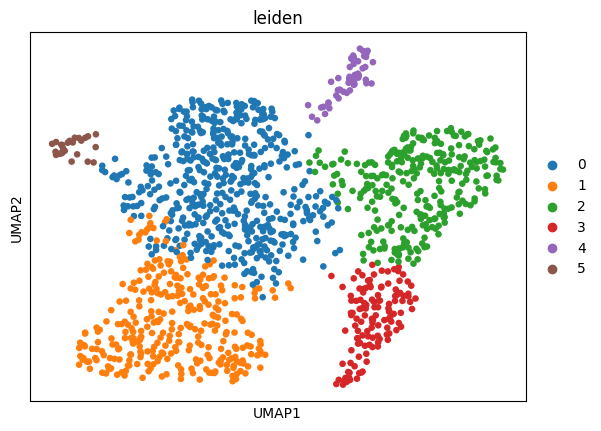

In [8]:
import scanpy as sc

# Leiden clustering
sdata = hp.tb.leiden(
    sdata,
    labels_name=f"labels_grid_{size}",
    table_name="table_superpixel_intensities_z_scored",
    output_table_name="table_superpixel_intensities_z_scored",
    calculate_umap=True,
    calculate_neighbors=True,
    n_pcs=17,  # The number of principal components to use when calculating neighbors.
    n_neighbors=35,  # The number of neighbors to consider when calculating neighbors.
    resolution=0.4,
    rank_genes=True,
    key_added="leiden",
    overwrite=True,
)

# Plot UMAP
sc.pl.umap(
    sdata.tables["table_superpixel_intensities_z_scored"],
    color=["leiden"],
    show=True,
)

<Axes: title={'center': 'Leiden clusters'}>

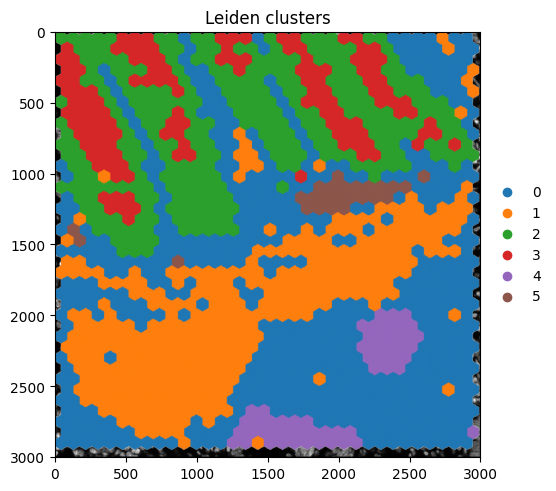

In [9]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    table_name="table_superpixel_intensities_z_scored",
    labels_name=f"labels_grid_{size}",
    color="leiden",
    to_coordinate_system="global_1",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={"title": "Leiden clusters", "colorbar": False},
)

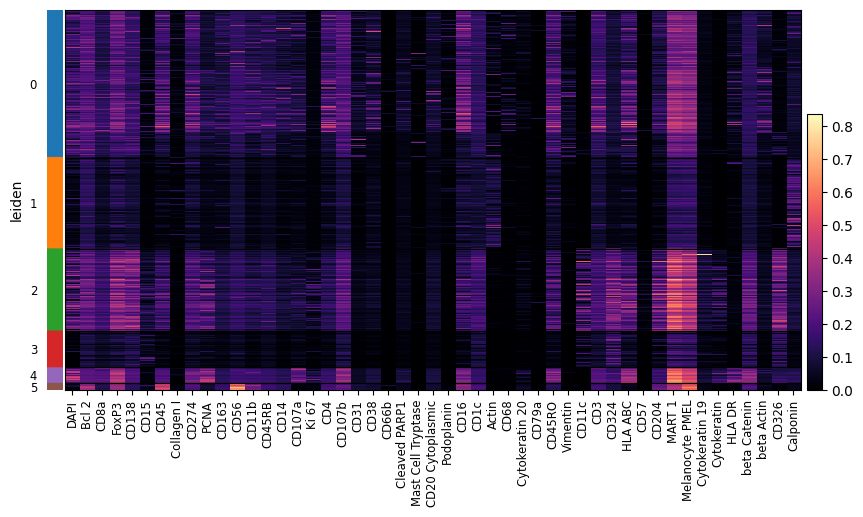

In [10]:
sc.pl.heatmap(
    sdata["table_superpixel_intensities_z_scored"],
    var_names=successful_channels,
    groupby="leiden",
    swap_axes=False,
    norm=None,
    cmap="magma",
    figsize=(10, 5),
    show_gene_labels=True,
)

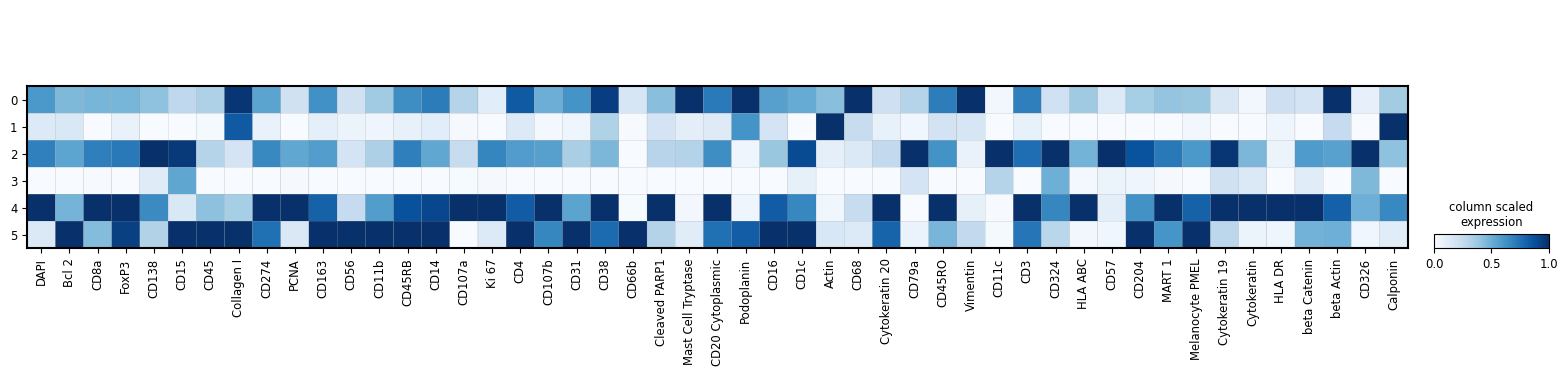

In [11]:
# Matrix plot
sc.pl.matrixplot(
    sdata.tables["table_superpixel_intensities_z_scored"],
    var_names=successful_channels,
    groupby="leiden",
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\nexpression",
)

## 2. Pixel clustering (FlowSOM)

### 2.1 Preprocessing

In [12]:
# The preprocessing step normalizes and blurs the images based on various quantile and gaussian blur parameters
sdata = hp.im.pixel_clustering_preprocess(
    sdata,
    image_name="REAscreen_IO_CRC",
    output_image_name="REAscreen_IO_CRC_flowsom",
    channels=successful_channels,
    p=99,  # Quantile used for normalization. Each channel is normalized by its own calculated quantile.
    p_sum=5,  # If the sum of the channel values at a pixel is below this quantile, the pixel values across all channels are set to NaN.
    p_post=99.9,  # Quantile used for normalization after other preprocessing steps (`q`, `q_sum`, `norm_sum` normalization and Gaussian blurring) are performed.
    sigma=2,  # Gaussian blur parameter for each channel. Use `0` to omit blurring for specific channels or `None` to skip blurring altogether.
    norm_sum=True,  # If `True`, each channel is normalized by the sum of all channels at each pixel.
    cap_max=1,  # The maximum allowable value for the elements in the resulting preprocessed image layers. If `None`, no capping is applied. Typical value would be `1.0` to exclude outliers.
    overwrite=True,
)

2026-05-27 14:58:41.628 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'REAscreen_IO_CRC_flowsom'


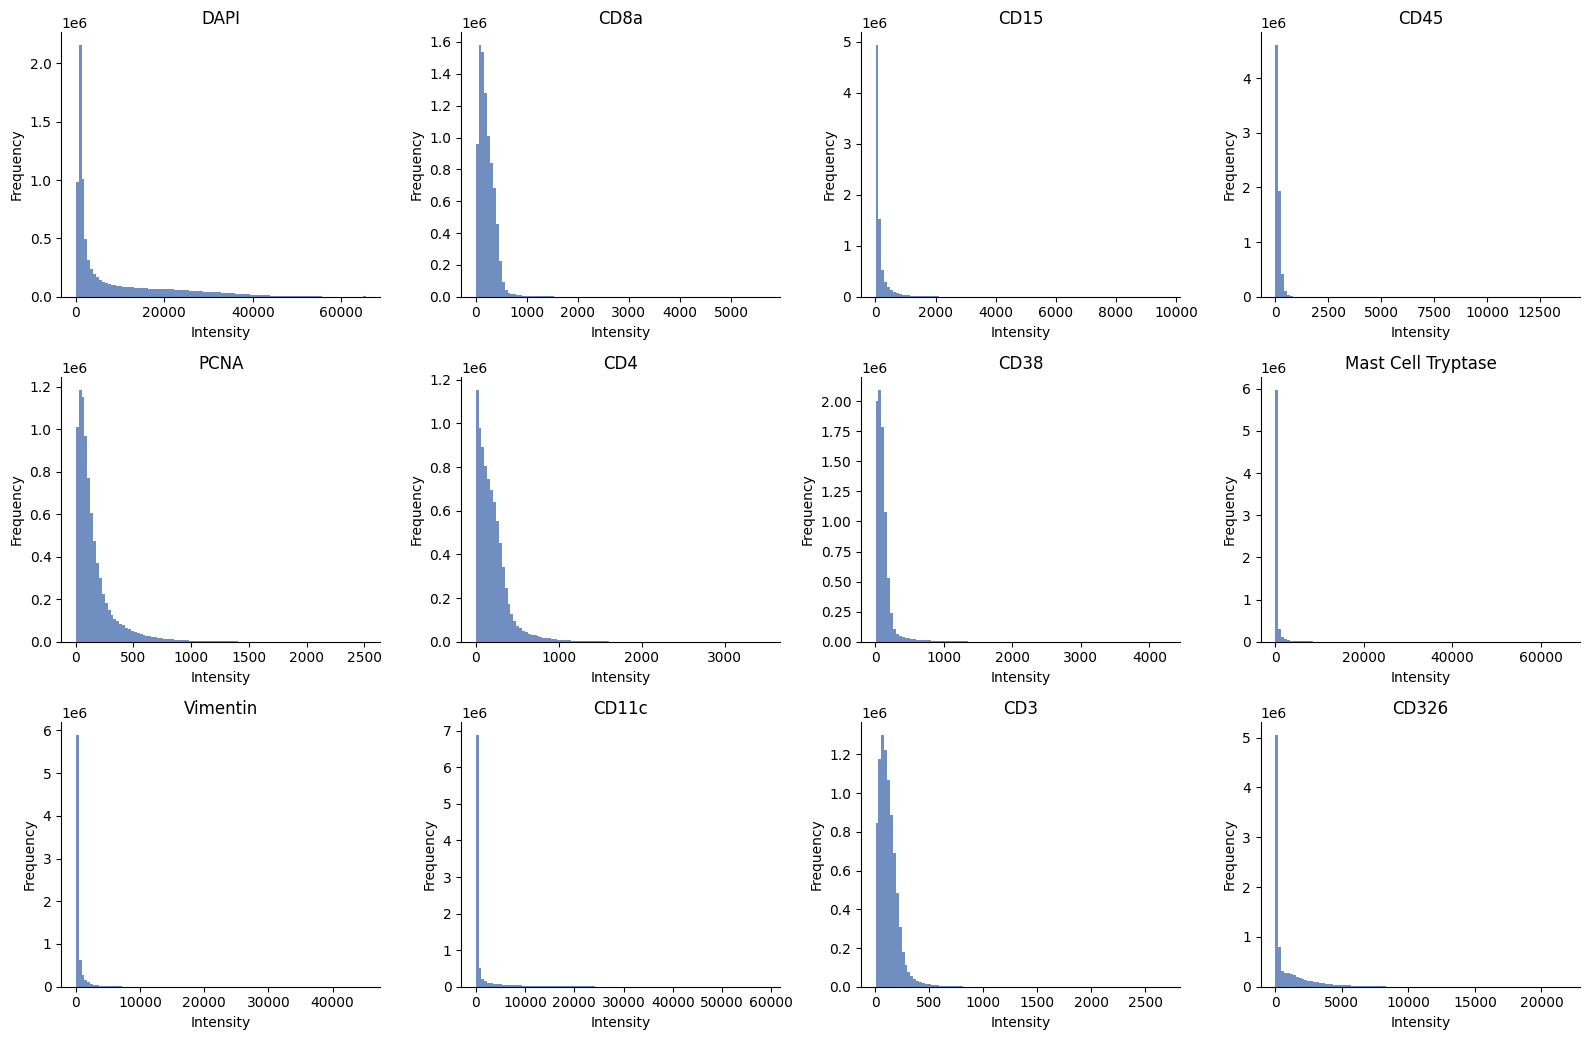

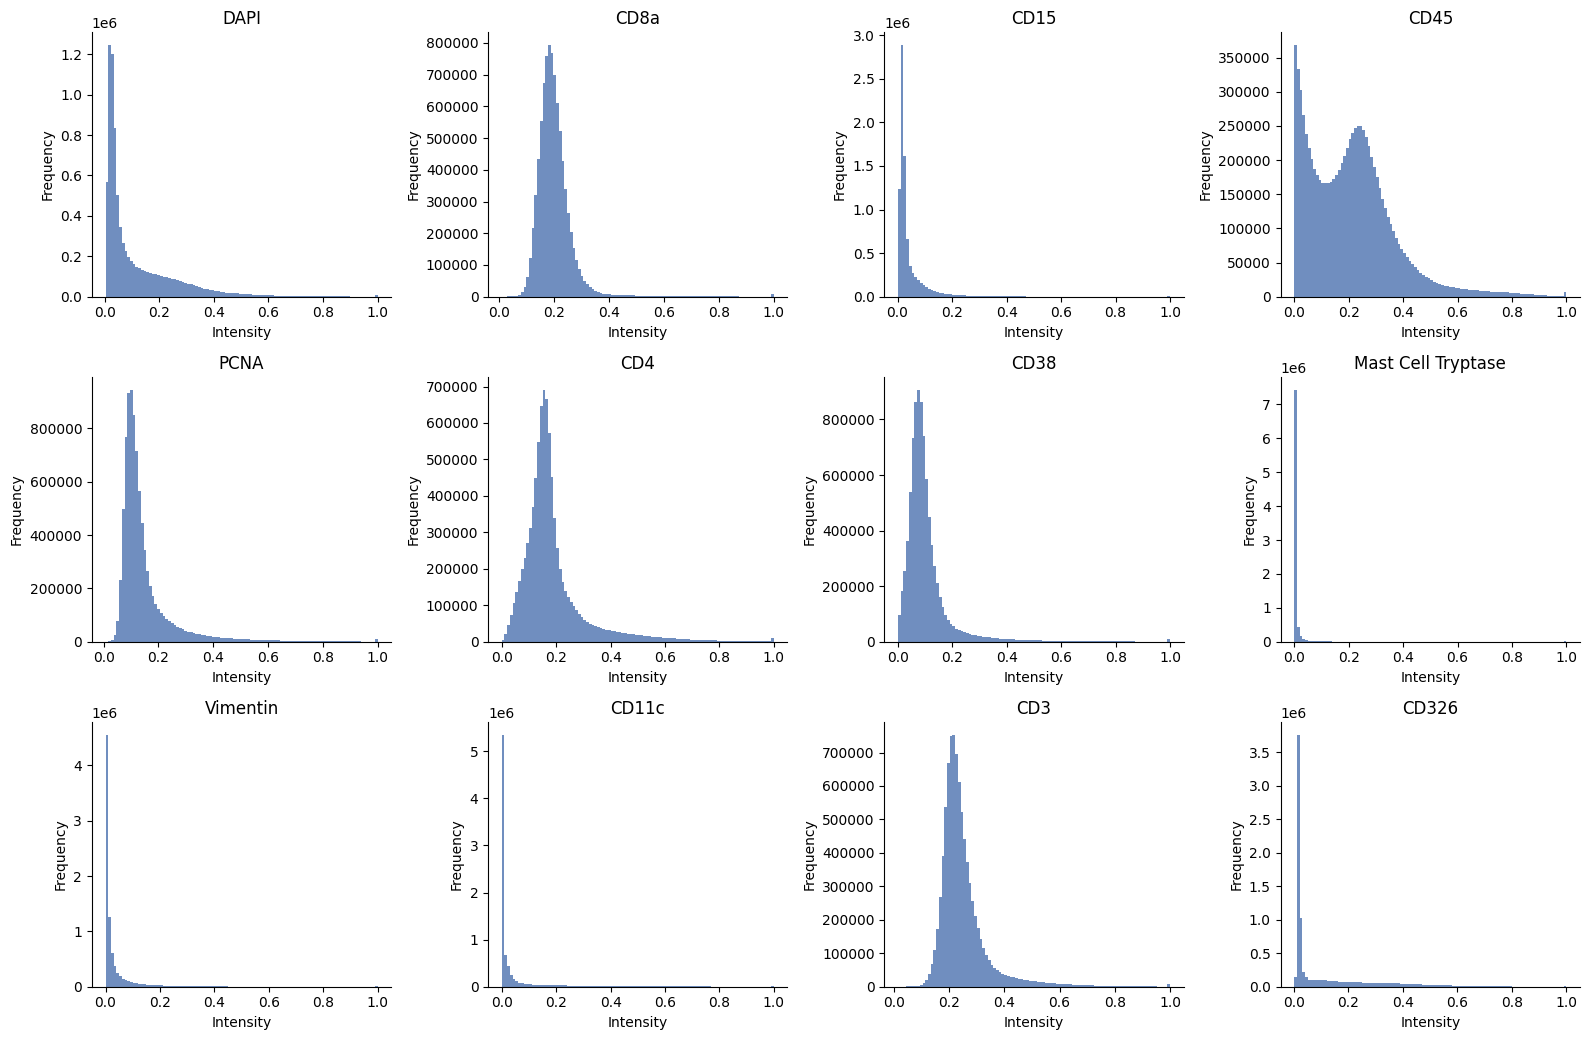

In [13]:
_channels_to_visualize = [
    "DAPI",
    "CD8a",
    "CD15",
    "CD45",
    "PCNA",
    "CD4",
    "CD38",
    "Mast Cell Tryptase",
    "Vimentin",
    "CD11c",
    "CD3",
    "CD326",
]

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

ax = hp.qc.image_histogram(
    sdata,
    image_name="REAscreen_IO_CRC_flowsom",
    channel=_channels_to_visualize,
    ncols=4,
    bins=100,
)

### 2.2 FlowSOM pixel clustering

In [14]:
# FlowSOM clustering
import flowsom as fs
from dask.distributed import Client, LocalCluster

work_with_client = False

if work_with_client:
    # client example
    cluster = LocalCluster(
        n_workers=1,
        threads_per_worker=10,
    )

    client = Client(cluster)
else:
    client = None

batch_model = fs.models.BatchFlowSOMEstimator

sdata_crop, fsom, mapping = hp.im.flowsom(
    sdata,
    image_name=["REAscreen_IO_CRC_flowsom"],
    output_cluster_labels_name=[
        "flowsom_clusters",
    ],  # we need output_cluster_labels and output_meta_cluster_labels --> these will both be labels elements
    output_metacluster_labels_name=[
        "flowsom_metaclusters",
    ],
    channels=successful_channels,
    fraction=0.1,  # Fraction of the data to sample for training flowsom.
    n_clusters=20,  # The number of meta clusters to form.
    random_state=111,
    chunks=512,
    client=client,
    model=batch_model,
    num_batches=10,
    xdim=10,
    ydim=10,
    z_score=False,
    z_cap=3,
    persist_intermediate=True,
    overwrite=True,
)

2026-05-27 14:59:00.111 | INFO     | harpy.image.pixel_clustering._clustering:flowsom:161 - Extracting random sample for FlowSOM training.
2026-05-27 14:59:03.807 | INFO     | harpy.image.pixel_clustering._clustering:_sample_dask_array:398 - Start sampling
2026-05-27 14:59:06.022 | INFO     | harpy.image.pixel_clustering._clustering:flowsom:219 - Start FlowSOM training.
2026-05-27 14:59:06.028 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-05-27 14:59:06.029 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.
2026-05-27 14:59:12.200 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.
2026-05-27 14:59:15.511 | INFO     | harpy.image.pixel_clustering._clustering:flowsom:221 - Finished FlowSOM training. Starting inference 
2026-05-27 14:59:19.460 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'flowsom_clusters'
no parent found for <ome_zarr.reader.Label object at 0x158f08170>: None
no parent found f

<Axes: title={'center': 'Metaclusters'}>

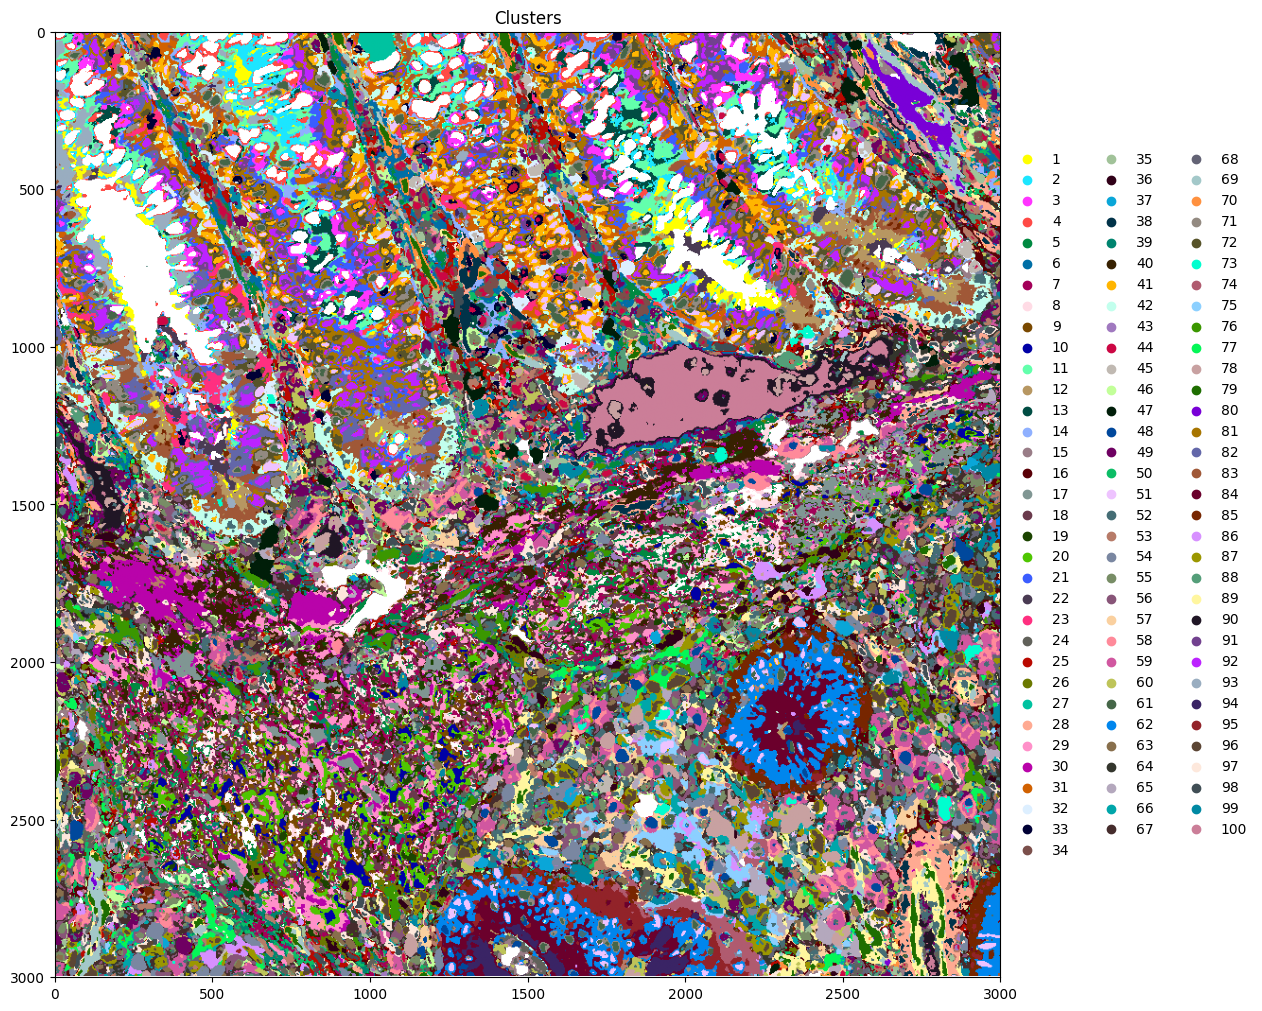

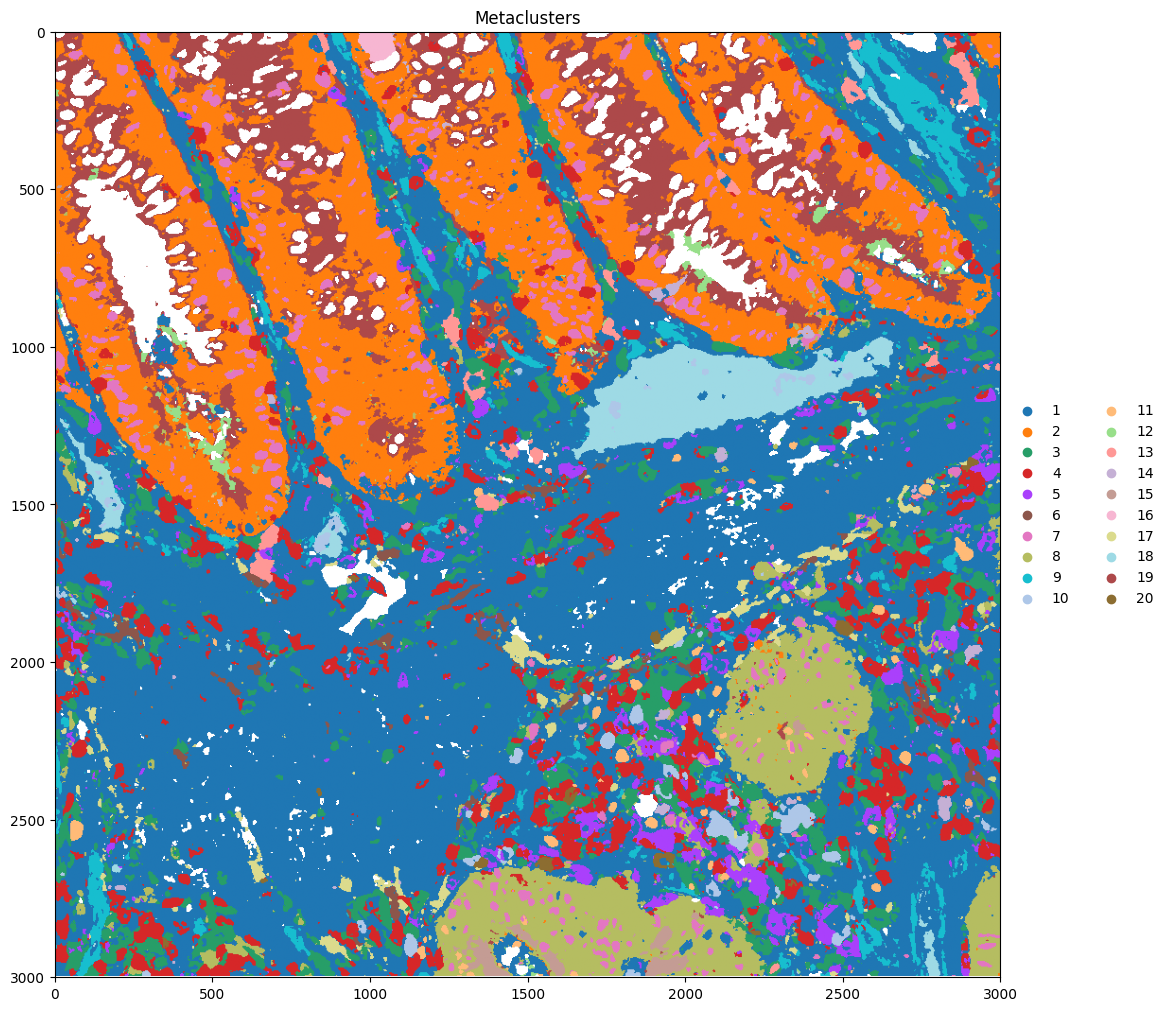

In [15]:
# Plot all FlowSOM clusters
hp.pl.pixel_clusters(
    sdata,
    labels_name="flowsom_clusters",
    figsize=(14, 10),
    to_coordinate_system="global_1",
    render_labels_kwargs={
        "fill_alpha": 1,
        "cmap": "rainbow",
    },
    coordinate_systems="global_1",
    title="Clusters",
)

# Plot FlowSOM metaclusters
hp.pl.pixel_clusters(
    sdata,
    labels_name="flowsom_metaclusters",
    figsize=(14, 10),
    to_coordinate_system="global",
    render_labels_kwargs={
        "fill_alpha": 1,
        "cmap": "rainbow",
    },
    coordinate_systems="global_1",
    title="Metaclusters",
)

2026-05-27 14:59:22.107 | INFO     | harpy.table.pixel_clustering._cluster_intensity:cluster_intensity_SOM:120 - Start allocation of intensities of image element with name 'REAscreen_IO_CRC_flowsom' by labels in labels element with name 'flowsom_clusters'.
2026-05-27 14:59:25.939 | INFO     | harpy.table.pixel_clustering._cluster_intensity:cluster_intensity_SOM:139 - End allocation of image element with name 'REAscreen_IO_CRC_flowsom' and labels element with name 'flowsom_clusters'.
2026-05-27 14:59:25.940 | INFO     | harpy.table.pixel_clustering._cluster_intensity:cluster_intensity_SOM:143 - Start preprocessing.
2026-05-27 14:59:25.941 | INFO     | harpy.table._preprocess:preprocess:318 - Calculating cell size from provided labels_name 'flowsom_clusters'
2026-05-27 14:59:26.038 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[raw_counts]'.
2026-05-27 14:59:27.077 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 -

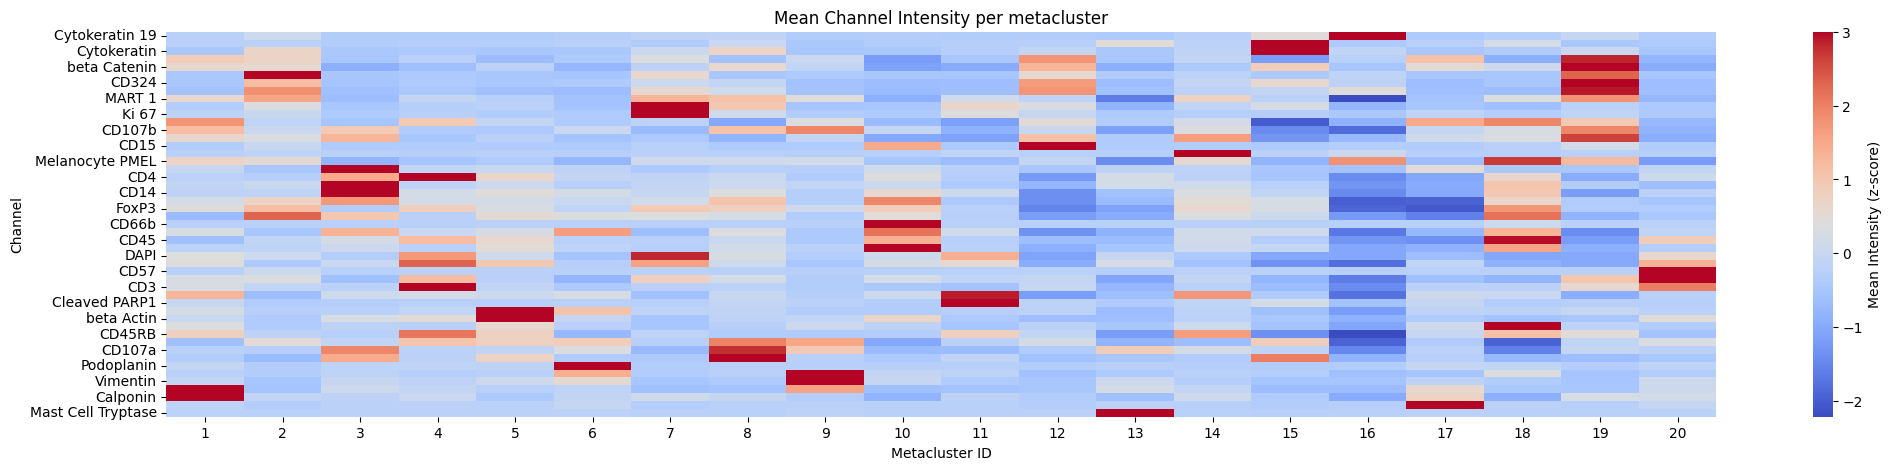

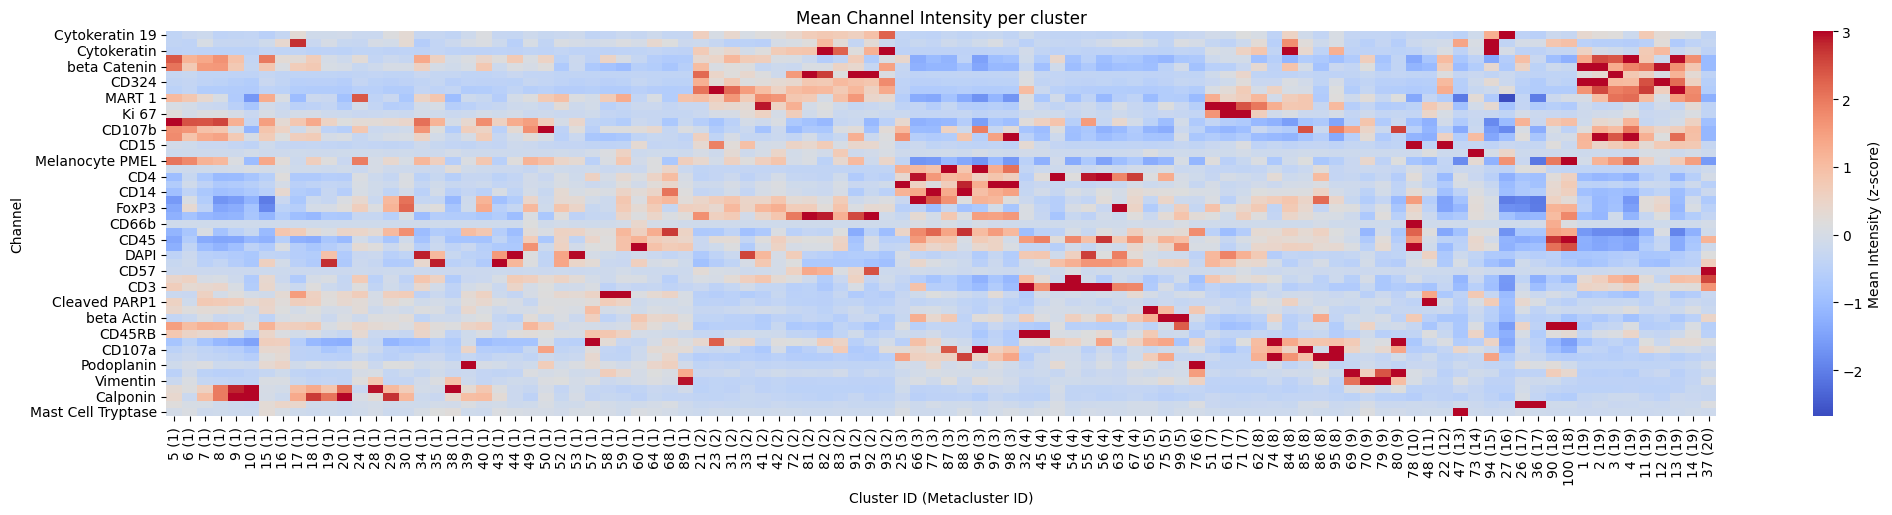

In [16]:
# calculate the mean itensity per metacluster, and then plot a heatmap.
cluster_key = "leiden"

sdata = hp.tb.cluster_intensity_SOM(
    sdata,
    mapping=mapping,
    image_name="REAscreen_IO_CRC_flowsom",
    labels_name="flowsom_clusters",
    to_coordinate_system="global_1",
    output_table_name="counts_clusters",
    overwrite=True,
)

for _metaclusters in [True, False]:
    hp.pl.pixel_clusters_heatmap(
        sdata,
        table_name="counts_clusters",
        figsize=(25, 5),
        fig_kwargs={"dpi": 100},
        linewidths=0.001,
        metaclusters=_metaclusters,
        z_score=True,
    )

### 2.3 Spatial enrichment FlowSOM metaclusters 

We can use hp.tb.spatial_pixel_neighbors() after calculating FlowSOM metaclusters to get neighborhood enrichment scores among metaclusters. This function extracts grid-based cluster labels from the specified labels layer of a SpatialData object,
subdivides the spatial domain into a grid using a specified sampling interval, and computes spatial neighbors along with
neighborhood enrichment statistics. The resulting AnnData object stores the cluster labels as a categorical
observation (under the key provided by `key_added`) and the corresponding spatial coordinates in its `.obsm`
attribute. `squidpy` is used for the spatial neighbors computation and
the neighborhood enrichment analysis (i.e. `squidpy.gr.spatial_neighbors` and `squidpy.gr.nhood_enrichment`).
Results can then be visualized using e.g. `squidpy.pl.nhood_enrichment`.

In [17]:
import harpy as hp

from spatialdata import read_zarr

sdata = read_zarr("/Users/arne.defauw/VIB/DATA/summer_school_2026/sdata_macsima.zarr")

no parent found for <ome_zarr.reader.Label object at 0x158de1eb0>: None
no parent found for <ome_zarr.reader.Label object at 0x1455b3230>: None
no parent found for <ome_zarr.reader.Label object at 0x159209a30>: None
no parent found for <ome_zarr.reader.Label object at 0x152b9c590>: None
no parent found for <ome_zarr.reader.Label object at 0x1594c1010>: None
no parent found for <ome_zarr.reader.Label object at 0x158e8dbe0>: None


2026-05-27 14:59:34.558 | INFO     | harpy.image._manager:add_element:47 - Writing results to element 'labels_grid_4a694937-e8dd-4763-85c6-a251d4170d83'
no parent found for <ome_zarr.reader.Label object at 0x1589f1190>: None
no parent found for <ome_zarr.reader.Label object at 0x159761a30>: None
no parent found for <ome_zarr.reader.Label object at 0x15980bc80>: None
no parent found for <ome_zarr.reader.Label object at 0x15978cf50>: None
no parent found for <ome_zarr.reader.Label object at 0x15979d130>: None
no parent found for <ome_zarr.reader.Label object at 0x1597a5af0>: None
no parent found for <ome_zarr.reader.Label object at 0x1597a4140>: None
2026-05-27 14:59:35.837 | INFO     | harpy.utils._featurize:__init__:93 - Calculating unique labels in the mask.
2026-05-27 14:59:35.887 | INFO     | harpy.utils._featurize:__init__:96 - Finished calculating unique labels in the mask.
2026-05-27 14:59:35.888 | INFO     | harpy.utils._featurize:extract_instances:795 - Calculating center of ma

INFO     Creating graph using `grid` coordinates and `None` transform and `1` libraries.                           


  0%|          | 0/1000 [00:00<?, ?/s]

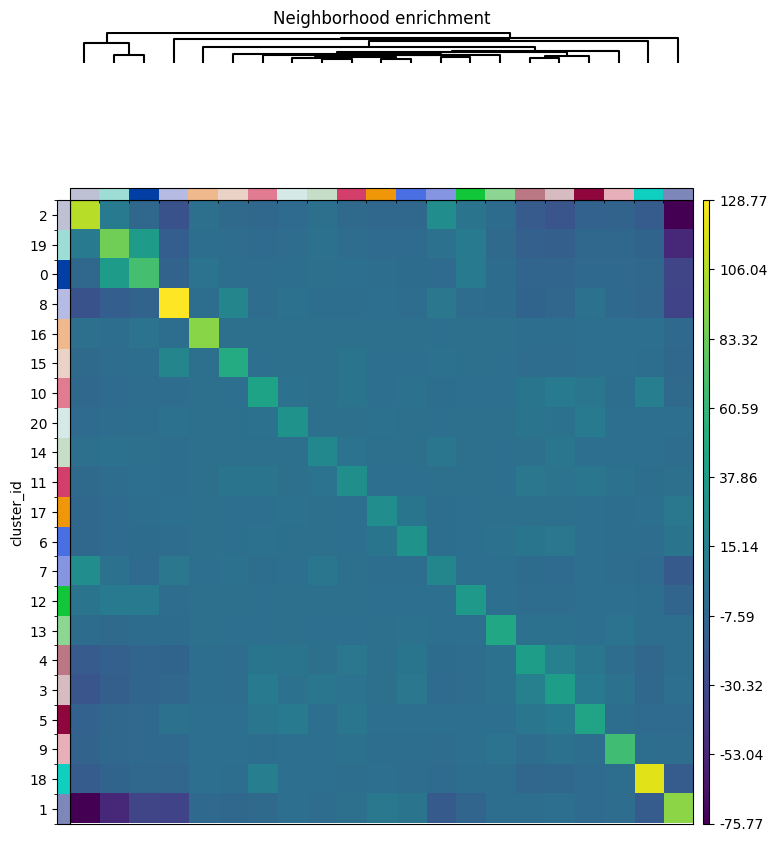

In [18]:
import numpy as np
import squidpy as sq


# @Julien : I would skip this. It does not show much...What do you think?

key_added = "cluster_id"

adata = hp.tb.spatial_pixel_neighbors(
    sdata,
    labels_name="flowsom_metaclusters",
    key_added=key_added,
    mode="most_frequent",
    grid_type="hexagon",
    size=20,
    subset=None,
)

adata.uns[f"{key_added}_nhood_enrichment"]["zscore"] = np.nan_to_num(
    adata.uns[f"{key_added}_nhood_enrichment"]["zscore"]
)
sq.pl.nhood_enrichment(
    adata, cluster_key=key_added, method="ward", mode="zscore", figsize=(8, 8)
)

# NOTE: cluster_id 0 contains all pixels that were filtered out during preprocessing

## 3. Cell clustering (FlowSOM)

In [19]:
# Assign cell types based on FlowSOM pixel metaclusters
import flowsom as fs

batch_model = fs.models.BatchFlowSOMEstimator

sdata_crop, fsom = hp.tb.flowsom(
    sdata,
    cells_labels_name="labels_cells_instanseg",
    cluster_labels_name=["flowsom_metaclusters"],
    output_table_name="table_cell_clustering_flowsom",
    n_clusters=15,
    chunks=512,
    model=batch_model,
    num_batches=10,
    random_state=100,
    overwrite=True,
)

2026-05-27 14:59:46.953 | INFO     | harpy.table._preprocess:preprocess:318 - Calculating cell size from provided labels_name 'labels_cells_instanseg'
2026-05-27 14:59:47.080 | INFO     | harpy.table._preprocess:preprocess:338 - Saving non preprocessed data matrix to the AnnData '.layers[raw_counts]'.
2026-05-27 14:59:48.303 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cell_clustering_flowsom' already exists. Overwriting...
2026-05-27 14:59:49.883 | DEBUG    | flowsom.main:__init__:82 - Reading input.
2026-05-27 14:59:49.883 | DEBUG    | flowsom.main:__init__:84 - Fitting model: clustering and metaclustering.
2026-05-27 14:59:49.900 | DEBUG    | flowsom.main:__init__:86 - Updating derived values.
2026-05-27 14:59:50.031 | INFO     | harpy.table.cell_clustering._clustering:flowsom:166 - Adding mean cluster intensity to '.uns['clustering']'
2026-05-27 14:59:50.043 | INFO     | harpy.table.cell_clustering._clustering:flowsom:166 - Adding mean cluster 

In [20]:
sdata["table_cell_clustering_flowsom"].obs.head()

,cell_ID,fov_labels,shapeSize,clustering,distance_to_bmu,metaclustering
cells,,,,,,
105_labels_cells_instanseg_7f4908b0,105,labels_cells_instanseg,1008.0,94,36.317707,5
129_labels_cells_instanseg_7f4908b0,129,labels_cells_instanseg,14.0,3,3.359237,10
133_labels_cells_instanseg_7f4908b0,133,labels_cells_instanseg,1389.0,90,4.964611,5
141_labels_cells_instanseg_7f4908b0,141,labels_cells_instanseg,813.0,3,3.359237,10
145_labels_cells_instanseg_7f4908b0,145,labels_cells_instanseg,885.0,3,3.359237,10


<Axes: title={'center': 'FlowSOM cell clusters'}>

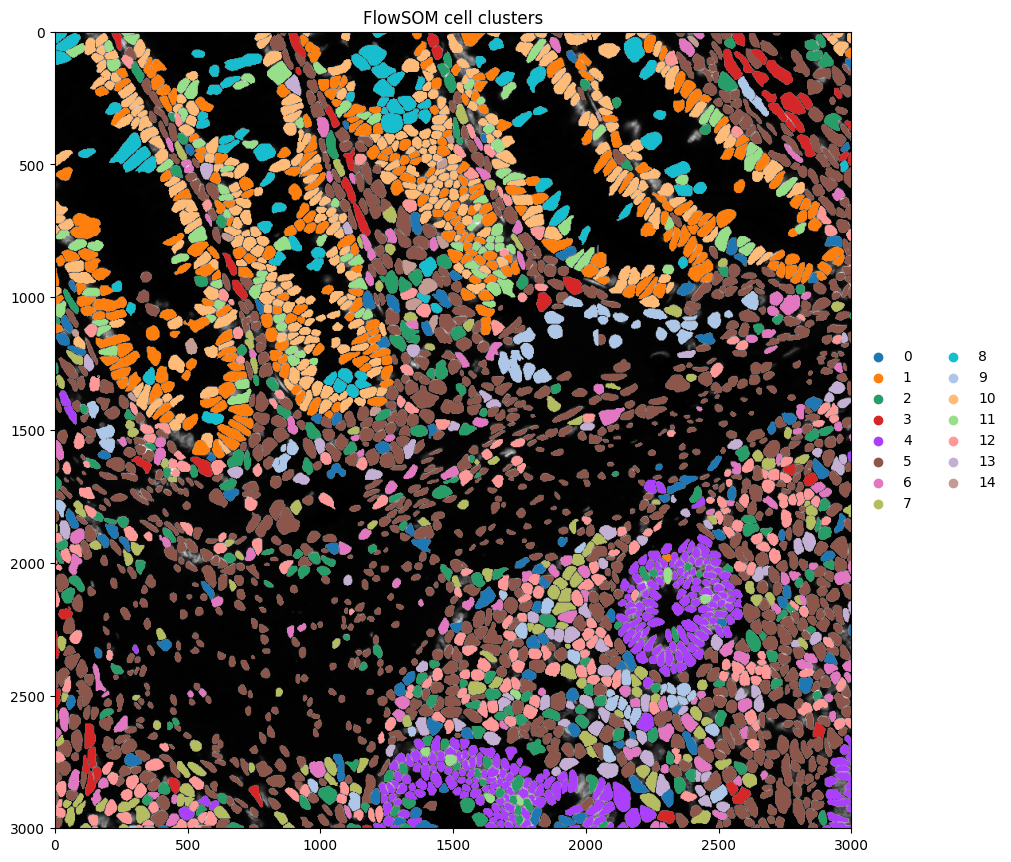

In [21]:
# Plot clusters spatially
hp.pl.plot_sdata(
    sdata,
    image_name="REAscreen_IO_CRC",
    channel="DAPI",
    table_name="table_cell_clustering_flowsom",
    labels_name="labels_cells_instanseg",
    color="metaclustering",
    to_coordinate_system="global_1",
    render_images_kwargs={"cmap": "grey"},
    render_labels_kwargs={"fill_alpha": 1},
    show_kwargs={
        "title": "FlowSOM cell clusters",
        "colorbar": False,
        "figsize": (10, 10),
    },
)

Now also add the calculated (via hp.tb.flowsom) cell metacluster and cluster ids to the table element "table_cells_z_scored_filterd". This will allow us to calculate mean intensity per assigned metacluster, the same way we did it for the leiden clusters.

In [22]:
import pandas as pd

instance_key = "cell_ID"
region_key = "fov_labels"

table_name = "table_cells_z_scored_filterd"
table_name_flowsom_cell_clustering = "table_cell_clustering_flowsom"
labels_name = "labels_cells_instanseg"

columns = ["metaclustering", "clustering", instance_key, region_key]

index = sdata[table_name].obs.index
name = sdata[table_name].obs.index.name

sdata[table_name].obs = pd.merge(
    sdata[table_name].obs,
    sdata[table_name_flowsom_cell_clustering].obs[columns],
    on=[instance_key, region_key],
    how="left",  # left merge, because in table "table_cell_clustering_flowsom", we removed cells with no overlap with any pixel cluster
)
sdata[table_name].obs.index = index
sdata[table_name].obs.index.name = name
sdata[table_name]

# back "table_cells_z_scored_filterd", now with metaclustering, clustering in .obs to zarr
sdata = hp.tb.add_table(
    sdata,
    adata=sdata[table_name],
    output_table_name=table_name,
    region=[labels_name],
    overwrite=True,
)

2026-05-27 15:00:01.614 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_z_scored_filterd' already exists. Overwriting...


In [23]:
sdata["table_cells_z_scored_filterd"].obs.head()

,cell_ID,fov_labels,perimeter,eccentricity,convex_area,area,filter_on_size,has_nucleus,leiden,shapeSize,metaclustering,clustering
cells,,,,,,,,,,,,
105_labels_cells_instanseg_a57cae0b,105,labels_cells_instanseg,22.182498,0.639923,30.8652,29.1312,False,True,8,1008.0,5,94
133_labels_cells_instanseg_a57cae0b,133,labels_cells_instanseg,30.026661,0.848078,43.2633,40.1421,False,True,2,1389.0,5,90
141_labels_cells_instanseg_a57cae0b,141,labels_cells_instanseg,22.634163,0.828831,25.4609,23.4957,False,True,1,813.0,10,3
145_labels_cells_instanseg_a57cae0b,145,labels_cells_instanseg,23.484163,0.618995,27.9752,25.5765,False,False,1,885.0,10,3
149_labels_cells_instanseg_a57cae0b,149,labels_cells_instanseg,22.762914,0.834278,27.0504,25.0563,False,True,5,867.0,10,3


2026-05-27 15:03:46.664 | INFO     | harpy.table._cluster_intensity:cluster_intensity:80 - Weighted (by instance size) average intensity per cluster (cluster key: 'metaclustering') will be stored in 'sdata[table_cells_z_scored_filterd].uns[metaclustering_weighted_intensity]'.
2026-05-27 15:03:46.680 | WARNING  | harpy.table._cluster_intensity:cluster_intensity:94 - Key 'metaclustering_weighted_intensity' found in sdata[table_cells_z_scored_filterd].uns. Object at that location will be removed and recalculated.
2026-05-27 15:03:51.311 | WARNING  | harpy.utils._io:_incremental_io_on_disk:86 - Element with name 'table_cells_z_scored_filterd' already exists. Overwriting...


Text(0.5, 80.7222222222222, 'cell metacluster')

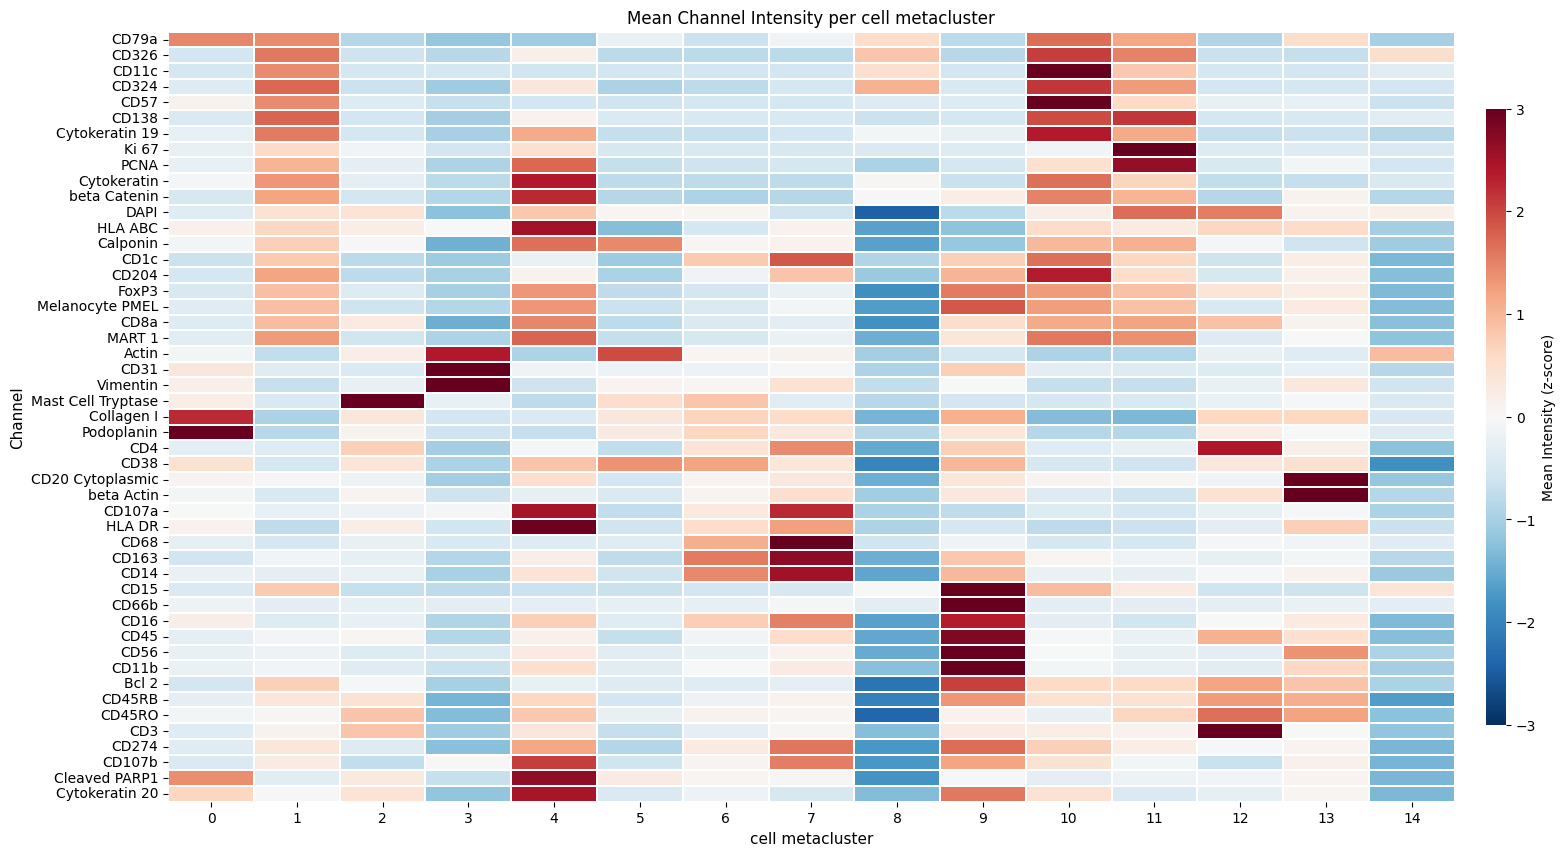

In [27]:
sdata = hp.tb.cluster_intensity(
    sdata,
    table_name=table_name,
    labels_name=labels_name,
    output_table_name=table_name,
    cluster_key="metaclustering",
    overwrite=True,
)

ax = hp.pl.cluster_intensity_heatmap(
    sdata,
    table_name=table_name,
    channels=successful_channels,
    cluster_key="metaclustering",
    figsize=(20, 10),
)
ax.set_title("Mean Channel Intensity per cell metacluster")
_x_label = "cell metacluster"

ax.set_ylabel("Channel")
ax.set_xlabel(_x_label)

In [ ]:
from napari_harpy import Interactive

Interactive(sdata)

2026-05-27 15:01:16.194 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:294 - No stored `metaclustering_colors` palette found in `table.uns`; using the default categorical palette for viewer coloring.
2026-05-27 15:01:39.965 | INFO     | napari_harpy.viewer.labels_styling:_resolve_categorical_palette:312 - Using stored `metaclustering_colors` palette from `table.uns` for viewer coloring.
